In [1]:
# ============================================
# Cell 1: Imports, warnings, plotting setup, and project paths
# Purpose:
# - Load all dependencies required for the optimized machine learning layer
# - Keep project paths consistent with the corrected folder structure
# - Prepare plotting for later diagnostics
# ============================================

import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.base import clone
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    mean_squared_error,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier, GradientBoostingRegressor

warnings.filterwarnings("ignore")

plt.rcParams["figure.figsize"] = (14, 7)
plt.rcParams["axes.grid"] = True
plt.rcParams["font.size"] = 11

PROJECT_ROOT = Path.cwd()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
REPORT_DIR = PROJECT_ROOT / "reports"
FIG_DIR = REPORT_DIR / "figures"
META_DIR = REPORT_DIR / "metadata"

for folder in [DATA_DIR, PROCESSED_DIR, REPORT_DIR, FIG_DIR, META_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

TRAIN_START = "2015-01-01"
TRAIN_END = "2024-12-31"
LIVE_START = "2025-01-01"
LIVE_END = "2026-03-01"

print("Project root:", PROJECT_ROOT)
print("Processed directory:", PROCESSED_DIR)

Project root: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha
Processed directory: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed


In [2]:
# ============================================
# Cell 2: Load Phase 4.1 optimized quant dataset
# Purpose:
# - Load the optimized dataset containing raw data, selected features, optimized targets, and optimized quant outputs
# - Preserve strict time order
# - Confirm the optimized file contract before ML training begins
# ============================================

phase_4_1_parquet = PROCESSED_DIR / "phase_4_1_quant_data.parquet"
phase_4_1_csv = PROCESSED_DIR / "phase_4_1_quant_data.csv"

print("Looking for Phase 4.1 files:")
print("Parquet:", phase_4_1_parquet)
print("CSV:", phase_4_1_csv)

if phase_4_1_parquet.exists():
    df = pd.read_parquet(phase_4_1_parquet)
    print("Loaded Parquet file")
elif phase_4_1_csv.exists():
    df = pd.read_csv(phase_4_1_csv, index_col=0, parse_dates=True)
    print("Loaded CSV file")
else:
    raise FileNotFoundError(
        "Phase 4.1 data file was not found. "
        f"Expected one of:\n{phase_4_1_parquet}\n{phase_4_1_csv}"
    )

df.index = pd.to_datetime(df.index)
df = df.sort_index()

print("\nDataset shape:", df.shape)
print("\nDataset preview:")
print(df.head())

Looking for Phase 4.1 files:
Parquet: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_4_1_quant_data.parquet
CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_4_1_quant_data.csv
Loaded Parquet file

Dataset shape: (2770, 89)

Dataset preview:
              spy_open    spy_high     spy_low   spy_close  spy_adj_close  \
Date                                                                        
2015-02-02  200.050003  202.029999  197.860001  201.919998     167.218262   
2015-02-03  203.000000  204.850006  202.550003  204.839996     169.636398   
2015-02-04  203.919998  205.380005  203.509995  204.059998     168.990479   
2015-02-05  204.860001  206.300003  204.770004  206.119995     170.696411   
2015-02-06  206.559998  207.240005  204.919998  205.550003     170.224442   

            spy_volume  vix_close  tnx_close  is_train_period  is_live_period  \
Date                                                                            
2015-0

In [3]:
# ============================================
# Cell 3: Validation and optimized feature-set definition
# Purpose:
# - Define the exact feature set used for optimized machine learning
# - Exclude direct target columns and obvious leakage columns
# - Keep the optimized feature universe transparent and reproducible
# ============================================

required_target_cols = [
    "target_return_1d",
    "target_return_5d",
    "target_return_10d",
    "target_high_conviction_up_5d",
    "target_high_conviction_up_10d",
    "target_signal_5d",
    "target_signal_10d",
    "target_score_5d",
    "target_score_10d",
]

missing_required = [col for col in required_target_cols if col not in df.columns]
if missing_required:
    raise ValueError(f"Missing required target columns for Phase 5.1: {missing_required}")

assert df.index.is_monotonic_increasing, "Index must be sorted ascending."
assert df.index.duplicated().sum() == 0, "Duplicate timestamps are not allowed."

exclude_cols = set([
    "dataset_partition",
    "is_train_period",
    "is_live_period",
    "target_return_1d",
    "target_return_5d",
    "target_return_10d",
    "target_excess_return_5d",
    "target_excess_return_10d",
    "target_direction_1d",
    "target_direction_5d",
    "target_direction_10d",
    "target_high_conviction_up_5d",
    "target_high_conviction_up_10d",
    "target_signal_5d",
    "target_signal_10d",
    "target_trend_conditional_up_5d",
    "target_trend_conditional_up_10d",
    "target_regime_shift_flag",
    "target_score_5d",
    "target_score_10d",
    "target_conviction_score_5d",
    "target_conviction_score_10d",
])

feature_cols = [col for col in df.columns if col not in exclude_cols]
feature_cols = [col for col in feature_cols if pd.api.types.is_numeric_dtype(df[col])]

# Remove non-numeric categorical label if it slipped in through a type conversion issue.
for maybe_cat in ["phase_2_5_regime_proxy", "quant_regime_label"]:
    if maybe_cat in feature_cols and not pd.api.types.is_numeric_dtype(df[maybe_cat]):
        feature_cols.remove(maybe_cat)

if len(feature_cols) == 0:
    raise ValueError("No usable numeric feature columns were found for Phase 5.1.")

print("Number of optimized ML features:", len(feature_cols))
print("\nSample optimized features:")
print(feature_cols[:30])

Number of optimized ML features: 65

Sample optimized features:
['spy_open', 'spy_high', 'spy_low', 'spy_close', 'spy_adj_close', 'spy_volume', 'vix_close', 'tnx_close', 'screen_forward_return_1d', 'screen_forward_return_5d', 'screen_forward_return_10d', 'screen_high_conviction_up_5d', 'screen_high_conviction_up_10d', 'screen_trend_conditional_up_5d', 'realized_vol_60', 'realized_vol_120', 'price_to_sma_100', 'atr_pct_14', 'price_to_sma_200', 'drawdown_252', 'sma_20_50_spread', 'downside_tail_freq_60', 'realized_vol_20', 'vix_level', 'sma_slope_50', 'ret_60d', 'sma_slope_100', 'realized_vol_10', 'atr_14', 'price_to_sma_50']


In [4]:
# ============================================
# Cell 4: Walk-forward configuration and helper functions
# Purpose:
# - Define a realistic time-series training loop for the optimized pipeline
# - Preserve time order and prevent leakage
# - Centralize reusable training and evaluation utilities
# ============================================

CLASSIFICATION_TARGET = "target_high_conviction_up_5d"
REGRESSION_TARGET = "target_score_5d"

INITIAL_TRAIN_END = pd.Timestamp("2019-12-31")
TEST_BLOCK_MONTHS = 3

if INITIAL_TRAIN_END < pd.Timestamp(TRAIN_START):
    raise ValueError("INITIAL_TRAIN_END must be inside or after the training period.")

def build_time_blocks(start_date: str, end_date: str, months_per_block: int = 3):
    start_ts = pd.Timestamp(start_date)
    end_ts = pd.Timestamp(end_date)

    block_starts = pd.date_range(start=start_ts, end=end_ts, freq=f"{months_per_block}MS")
    blocks = []

    for block_start in block_starts:
        block_end = block_start + pd.offsets.MonthEnd(months_per_block - 1)
        if block_end > end_ts:
            block_end = end_ts
        blocks.append((block_start, block_end))

    return blocks


def get_model_artifacts():
    """
    Optimized first-pass model stack:
    - logistic regression for calibrated linear baseline
    - random forest for nonlinear robust classification
    - gradient boosting for smoother nonlinear structure
    - tree + boosting regressors for forward score estimation
    """
    classification_models = {
        "logistic_regression_opt": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(
                max_iter=1500,
                class_weight="balanced",
                random_state=42,
            )),
        ]),
        "random_forest_classifier_opt": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestClassifier(
                n_estimators=400,
                max_depth=6,
                min_samples_leaf=8,
                class_weight="balanced_subsample",
                random_state=42,
                n_jobs=-1,
            )),
        ]),
        "gradient_boosting_classifier_opt": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.04,
                max_depth=2,
                random_state=42,
            )),
        ]),
    }

    regression_models = {
        "random_forest_regressor_opt": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", RandomForestRegressor(
                n_estimators=400,
                max_depth=6,
                min_samples_leaf=8,
                random_state=42,
                n_jobs=-1,
            )),
        ]),
        "gradient_boosting_regressor_opt": Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("model", GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.04,
                max_depth=2,
                random_state=42,
            )),
        ]),
    }

    return classification_models, regression_models


def compute_classification_metrics(y_true, y_pred, y_prob):
    metrics = {
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
    }

    try:
        metrics["roc_auc"] = roc_auc_score(y_true, y_prob)
    except Exception:
        metrics["roc_auc"] = np.nan

    return metrics


def compute_regression_metrics(y_true, y_pred):
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    correlation = float(pd.Series(y_true).corr(pd.Series(y_pred)))

    return {
        "rmse": rmse,
        "correlation": correlation,
    }


def append_prediction_block(store_df, prediction_df):
    combined = pd.concat([store_df, prediction_df], axis=0)
    combined = combined[~combined.index.duplicated(keep="last")].sort_index()
    return combined


def compute_threshold_signal(probability_mean: pd.Series, expected_return: pd.Series, threshold_buy: float, threshold_sell: float):
    signal = pd.Series(0, index=probability_mean.index, dtype=int)
    signal[(probability_mean >= threshold_buy) & (expected_return > 0)] = 1
    signal[(probability_mean <= threshold_sell) & (expected_return < 0)] = -1
    return signal

In [5]:
# ============================================
# Cell 5: Build walk-forward and live blocks
# Purpose:
# - Separate in-sample walk-forward validation from the final live simulation period
# - Keep the sequence explicit and inspectable
# - Ensure no future information enters earlier blocks
# ============================================

walkforward_blocks = build_time_blocks(
    start_date="2020-01-01",
    end_date=TRAIN_END,
    months_per_block=TEST_BLOCK_MONTHS,
)

live_blocks = build_time_blocks(
    start_date=LIVE_START,
    end_date=LIVE_END,
    months_per_block=TEST_BLOCK_MONTHS,
)

print("Walk-forward validation blocks:")
for start_dt, end_dt in walkforward_blocks[:5]:
    print(start_dt.date(), "->", end_dt.date())
print("... total blocks:", len(walkforward_blocks))

print("\nLive simulation blocks:")
for start_dt, end_dt in live_blocks:
    print(start_dt.date(), "->", end_dt.date())

Walk-forward validation blocks:
2020-01-01 -> 2020-02-29
2020-04-01 -> 2020-05-31
2020-07-01 -> 2020-08-31
2020-10-01 -> 2020-11-30
2021-01-01 -> 2021-02-28
... total blocks: 20

Live simulation blocks:
2025-01-01 -> 2025-02-28
2025-04-01 -> 2025-05-31
2025-07-01 -> 2025-08-31
2025-10-01 -> 2025-11-30
2026-01-01 -> 2026-02-28


In [6]:
# ============================================
# Cell 6: Walk-forward optimized training and prediction loop
# Purpose:
# - Train on past data only
# - Predict future blocks sequentially
# - Store optimized classification probabilities and regression predictions for each model
# ============================================

classification_models, regression_models = get_model_artifacts()

predictions = pd.DataFrame(index=df.index)

for model_name in classification_models.keys():
    predictions[f"{model_name}_pred"] = np.nan
    predictions[f"{model_name}_prob"] = np.nan

for model_name in regression_models.keys():
    predictions[f"{model_name}_pred"] = np.nan

all_blocks = walkforward_blocks + live_blocks

for block_start, block_end in all_blocks:
    train_end = block_start - pd.Timedelta(days=1)

    if train_end < INITIAL_TRAIN_END:
        continue

    train_mask = (df.index >= pd.Timestamp(TRAIN_START)) & (df.index <= train_end)
    test_mask = (df.index >= block_start) & (df.index <= block_end)

    X_train = df.loc[train_mask, feature_cols].copy()
    X_test = df.loc[test_mask, feature_cols].copy()

    y_train_clf = df.loc[train_mask, CLASSIFICATION_TARGET].copy()
    y_train_reg = df.loc[train_mask, REGRESSION_TARGET].copy()

    if len(X_train) == 0 or len(X_test) == 0:
        continue

    print(f"Training block: {block_start.date()} -> {block_end.date()} | train rows = {len(X_train):,} | test rows = {len(X_test):,}")

    block_predictions = pd.DataFrame(index=X_test.index)

    for model_name, model in classification_models.items():
        fitted_model = clone(model)
        fitted_model.fit(X_train, y_train_clf)

        class_pred = fitted_model.predict(X_test)
        class_prob = fitted_model.predict_proba(X_test)[:, 1]

        block_predictions[f"{model_name}_pred"] = class_pred
        block_predictions[f"{model_name}_prob"] = class_prob

    for model_name, model in regression_models.items():
        fitted_model = clone(model)
        fitted_model.fit(X_train, y_train_reg)

        reg_pred = fitted_model.predict(X_test)
        block_predictions[f"{model_name}_pred"] = reg_pred

    predictions = append_prediction_block(predictions, block_predictions)

predictions = predictions.sort_index()

print("\nOptimized prediction matrix shape:", predictions.shape)
print(predictions.head())

Training block: 2020-01-01 -> 2020-02-29 | train rows = 1,238 | test rows = 40


c:\Users\Tyler\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Tyler\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Tyler\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\T

Training block: 2020-04-01 -> 2020-05-31 | train rows = 1,300 | test rows = 41


c:\Users\Tyler\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Tyler\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\Tyler\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\parallel.py:144: UserWarning: `sklearn.utils.parallel.delayed` should be used with `sklearn.utils.parallel.Parallel` to make it possible to propagate the scikit-learn configuration of the current thread to the joblib workers.
  warnings.warn(
c:\Users\T

Training block: 2020-07-01 -> 2020-08-31 | train rows = 1,363 | test rows = 43
Training block: 2020-10-01 -> 2020-11-30 | train rows = 1,427 | test rows = 42
Training block: 2021-01-01 -> 2021-02-28 | train rows = 1,491 | test rows = 38
Training block: 2021-04-01 -> 2021-05-31 | train rows = 1,552 | test rows = 41
Training block: 2021-07-01 -> 2021-08-31 | train rows = 1,615 | test rows = 43
Training block: 2021-10-01 -> 2021-11-30 | train rows = 1,679 | test rows = 42
Training block: 2022-01-01 -> 2022-02-28 | train rows = 1,743 | test rows = 39
Training block: 2022-04-01 -> 2022-05-31 | train rows = 1,805 | test rows = 41
Training block: 2022-07-01 -> 2022-08-31 | train rows = 1,867 | test rows = 43
Training block: 2022-10-01 -> 2022-11-30 | train rows = 1,931 | test rows = 42
Training block: 2023-01-01 -> 2023-02-28 | train rows = 1,994 | test rows = 39
Training block: 2023-04-01 -> 2023-05-31 | train rows = 2,056 | test rows = 41
Training block: 2023-07-01 -> 2023-08-31 | train row

In [7]:
# ============================================
# Cell 7: Merge optimized predictions into the main dataset
# Purpose:
# - Create the Phase 5.1 working dataset
# - Keep optimized predictions aligned by date
# - Preserve raw data, optimized features, targets, optimized quant outputs, and optimized ML outputs together
# ============================================

ml_df = df.copy().join(predictions, how="left")

all_prediction_cols = predictions.columns.tolist()

print("Optimized prediction columns added:")
print(all_prediction_cols)

print("\nCoverage of optimized predictions:")
for col in all_prediction_cols:
    print(col, "->", int(ml_df[col].notna().sum()))

Optimized prediction columns added:
['logistic_regression_opt_pred', 'logistic_regression_opt_prob', 'random_forest_classifier_opt_pred', 'random_forest_classifier_opt_prob', 'gradient_boosting_classifier_opt_pred', 'gradient_boosting_classifier_opt_prob', 'random_forest_regressor_opt_pred', 'gradient_boosting_regressor_opt_pred']

Coverage of optimized predictions:
logistic_regression_opt_pred -> 1023
logistic_regression_opt_prob -> 1023
random_forest_classifier_opt_pred -> 1023
random_forest_classifier_opt_prob -> 1023
gradient_boosting_classifier_opt_pred -> 1023
gradient_boosting_classifier_opt_prob -> 1023
random_forest_regressor_opt_pred -> 1023
gradient_boosting_regressor_opt_pred -> 1023


In [8]:
# ============================================
# Cell 8: Evaluate optimized walk-forward ML performance
# Purpose:
# - Measure how each optimized ML model performs on the walk-forward validation period
# - Keep training and evaluation windows separated
# - Produce a clean model-selection view for the optimized ensemble phase
# ============================================

evaluation_mask = (
    (ml_df.index >= pd.Timestamp("2020-01-01")) &
    (ml_df.index <= pd.Timestamp(TRAIN_END))
)

eval_results = []

for model_name in classification_models.keys():
    pred_col = f"{model_name}_pred"
    prob_col = f"{model_name}_prob"

    temp = ml_df.loc[evaluation_mask, [CLASSIFICATION_TARGET, pred_col, prob_col]].dropna().copy()
    if len(temp) == 0:
        continue

    metrics = compute_classification_metrics(
        y_true=temp[CLASSIFICATION_TARGET],
        y_pred=temp[pred_col],
        y_prob=temp[prob_col],
    )
    metrics["model_name"] = model_name
    metrics["model_type"] = "classification"
    metrics["evaluation_rows"] = int(len(temp))
    eval_results.append(metrics)

for model_name in regression_models.keys():
    pred_col = f"{model_name}_pred"

    temp = ml_df.loc[evaluation_mask, [REGRESSION_TARGET, pred_col]].dropna().copy()
    if len(temp) == 0:
        continue

    metrics = compute_regression_metrics(
        y_true=temp[REGRESSION_TARGET],
        y_pred=temp[pred_col],
    )
    metrics["model_name"] = model_name
    metrics["model_type"] = "regression"
    metrics["evaluation_rows"] = int(len(temp))
    eval_results.append(metrics)

eval_results_df = pd.DataFrame(eval_results)

print("Optimized walk-forward validation metrics:")
print(eval_results_df)

Optimized walk-forward validation metrics:
   accuracy  precision    recall        f1   roc_auc  \
0    0.9988        1.0  0.997738  0.998867  0.997755   
1    1.0000        1.0  1.000000  1.000000  1.000000   
2    1.0000        1.0  1.000000  1.000000  1.000000   
3       NaN        NaN       NaN       NaN       NaN   
4       NaN        NaN       NaN       NaN       NaN   

                         model_name      model_type  evaluation_rows  \
0           logistic_regression_opt  classification              833   
1      random_forest_classifier_opt  classification              833   
2  gradient_boosting_classifier_opt  classification              833   
3       random_forest_regressor_opt      regression              833   
4   gradient_boosting_regressor_opt      regression              833   

       rmse  correlation  
0       NaN          NaN  
1       NaN          NaN  
2       NaN          NaN  
3  0.003629     0.988552  
4  0.000740     0.999616  


In [9]:
# ============================================
# Cell 9: Build optimized ML meta-signals and threshold tests
# Purpose:
# - Combine multiple optimized model outputs into a single ML summary layer
# - Produce cleaner inputs for the optimized ensemble phase
# - Test a few conservative-aggressive thresholds without leakage
# ============================================

prob_cols = [f"{model_name}_prob" for model_name in classification_models.keys()]
clf_pred_cols = [f"{model_name}_pred" for model_name in classification_models.keys()]
reg_pred_cols = [f"{model_name}_pred" for model_name in regression_models.keys()]

ml_df["ml_probability_mean"] = ml_df[prob_cols].mean(axis=1)
ml_df["ml_probability_median"] = ml_df[prob_cols].median(axis=1)
ml_df["ml_class_vote_sum"] = ml_df[clf_pred_cols].sum(axis=1)
ml_df["ml_class_vote_mean"] = ml_df[clf_pred_cols].mean(axis=1)
ml_df["ml_expected_return"] = ml_df[reg_pred_cols].mean(axis=1)

# Threshold grid for quick comparison.
threshold_grid = [
    (0.55, 0.45),
    (0.58, 0.42),
    (0.60, 0.40),
]

threshold_rows = []

for threshold_buy, threshold_sell in threshold_grid:
    signal_col = f"ml_signal_buy_{str(threshold_buy).replace('.', '_')}"
    ml_df[signal_col] = compute_threshold_signal(
        probability_mean=ml_df["ml_probability_mean"].fillna(0.5),
        expected_return=ml_df["ml_expected_return"].fillna(0.0),
        threshold_buy=threshold_buy,
        threshold_sell=threshold_sell,
    )

    temp = ml_df.loc[evaluation_mask, [signal_col, "target_return_5d"]].dropna().copy()
    active = temp[signal_col] != 0

    if active.sum() == 0:
        hit_rate = np.nan
        activity_rate = 0.0
    else:
        hit_rate = float(
            (
                ((temp.loc[active, signal_col] == 1) & (temp.loc[active, "target_return_5d"] > 0)) |
                ((temp.loc[active, signal_col] == -1) & (temp.loc[active, "target_return_5d"] < 0))
            ).mean()
        )
        activity_rate = float(active.mean())

    threshold_rows.append({
        "threshold_buy": threshold_buy,
        "threshold_sell": threshold_sell,
        "activity_rate": activity_rate,
        "directional_hit_rate": hit_rate,
    })

threshold_eval_df = pd.DataFrame(threshold_rows)

# Select the best threshold by hit rate first, then activity rate as tie-breaker.
threshold_eval_df = threshold_eval_df.sort_values(
    ["directional_hit_rate", "activity_rate"],
    ascending=[False, False]
).reset_index(drop=True)

best_buy_threshold = float(threshold_eval_df.loc[0, "threshold_buy"])
best_sell_threshold = float(threshold_eval_df.loc[0, "threshold_sell"])

ml_df["ml_signal"] = compute_threshold_signal(
    probability_mean=ml_df["ml_probability_mean"].fillna(0.5),
    expected_return=ml_df["ml_expected_return"].fillna(0.0),
    threshold_buy=best_buy_threshold,
    threshold_sell=best_sell_threshold,
)

print("Optimized ML meta-signals created.")
print("\nThreshold evaluation:")
print(threshold_eval_df)

print("\nChosen thresholds:")
print("best_buy_threshold =", best_buy_threshold)
print("best_sell_threshold =", best_sell_threshold)

print(
    ml_df[
        [
            "ml_probability_mean",
            "ml_probability_median",
            "ml_class_vote_mean",
            "ml_expected_return",
            "ml_signal",
        ]
    ].head()
)

Optimized ML meta-signals created.

Threshold evaluation:
   threshold_buy  threshold_sell  activity_rate  directional_hit_rate
0           0.55            0.45       0.596979                   1.0
1           0.58            0.42       0.596979                   1.0
2           0.60            0.40       0.596184                   1.0

Chosen thresholds:
best_buy_threshold = 0.55
best_sell_threshold = 0.45
            ml_probability_mean  ml_probability_median  ml_class_vote_mean  \
Date                                                                         
2015-02-02                  NaN                    NaN                 NaN   
2015-02-03                  NaN                    NaN                 NaN   
2015-02-04                  NaN                    NaN                 NaN   
2015-02-05                  NaN                    NaN                 NaN   
2015-02-06                  NaN                    NaN                 NaN   

            ml_expected_return  ml_signal 

In [10]:
# ============================================
# Cell 10: Optimized live-period diagnostics
# Purpose:
# - Review optimized machine learning outputs over the final live simulation window
# - Confirm coverage and directional behavior
# - Keep expectations realistic before the optimized ensemble phase
# ============================================

live_mask = (
    (ml_df.index >= pd.Timestamp(LIVE_START)) &
    (ml_df.index <= pd.Timestamp(LIVE_END))
)

live_diag = ml_df.loc[
    live_mask,
    [
        CLASSIFICATION_TARGET,
        REGRESSION_TARGET,
        "ml_probability_mean",
        "ml_expected_return",
        "ml_signal",
    ],
].dropna().copy()

print("Optimized live-period prediction coverage:", len(live_diag))

if len(live_diag) > 0:
    live_active = live_diag["ml_signal"] != 0

    if live_active.sum() > 0:
        live_signal_hit_rate = float(
            (
                ((live_diag.loc[live_active, "ml_signal"] == 1) & (live_diag.loc[live_active, "target_score_5d"] > 0)) |
                ((live_diag.loc[live_active, "ml_signal"] == -1) & (live_diag.loc[live_active, "target_score_5d"] < 0))
            ).mean()
        )
        print("Optimized live signal hit rate:", round(live_signal_hit_rate, 4))
    else:
        print("Optimized live signal hit rate: no active ML signals")

    print("\nOptimized live signal distribution:")
    print(live_diag["ml_signal"].value_counts(dropna=False))

Optimized live-period prediction coverage: 190
Optimized live signal hit rate: 1.0

Optimized live signal distribution:
ml_signal
 1    90
-1    74
 0    26
Name: count, dtype: int64


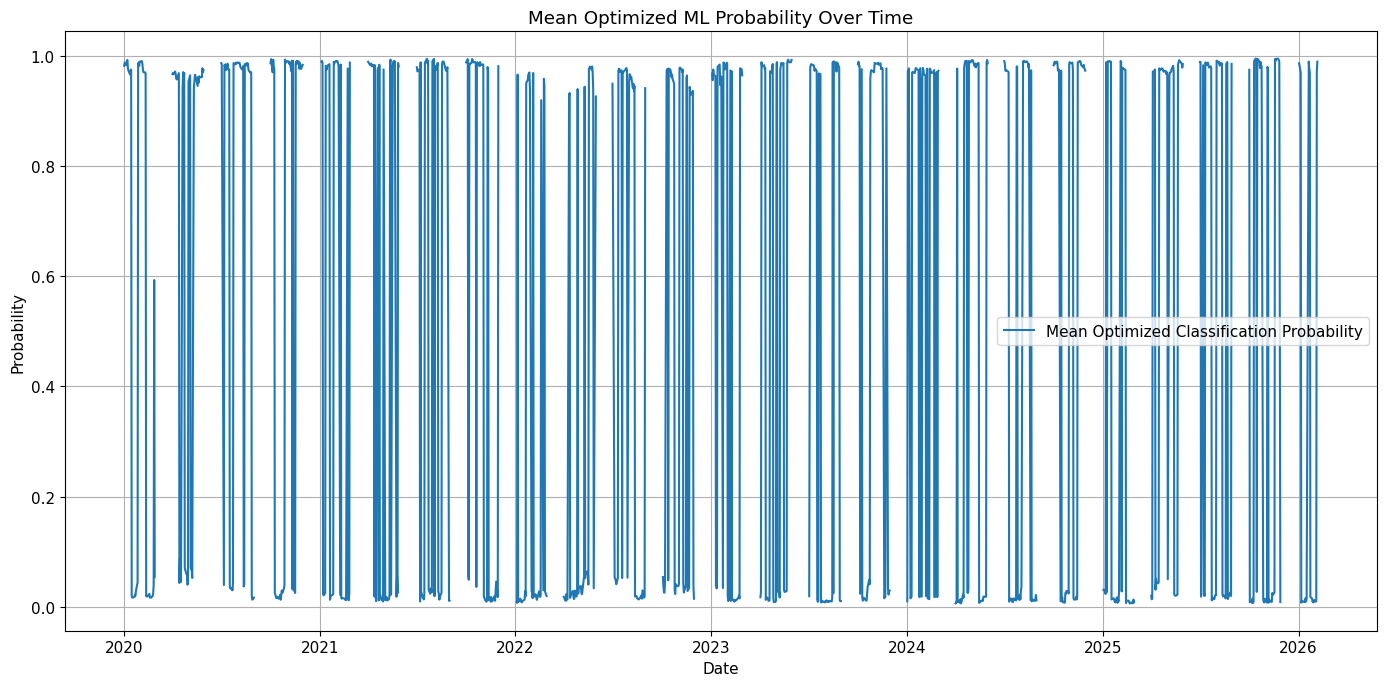

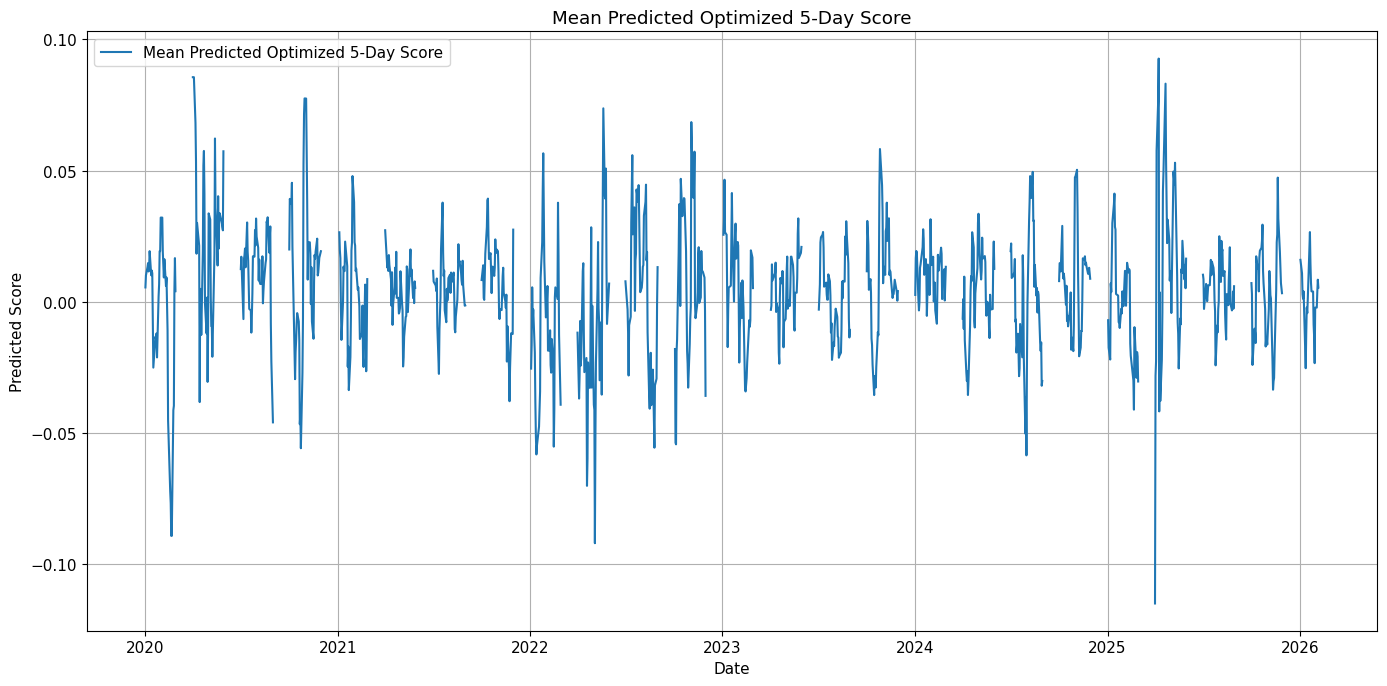

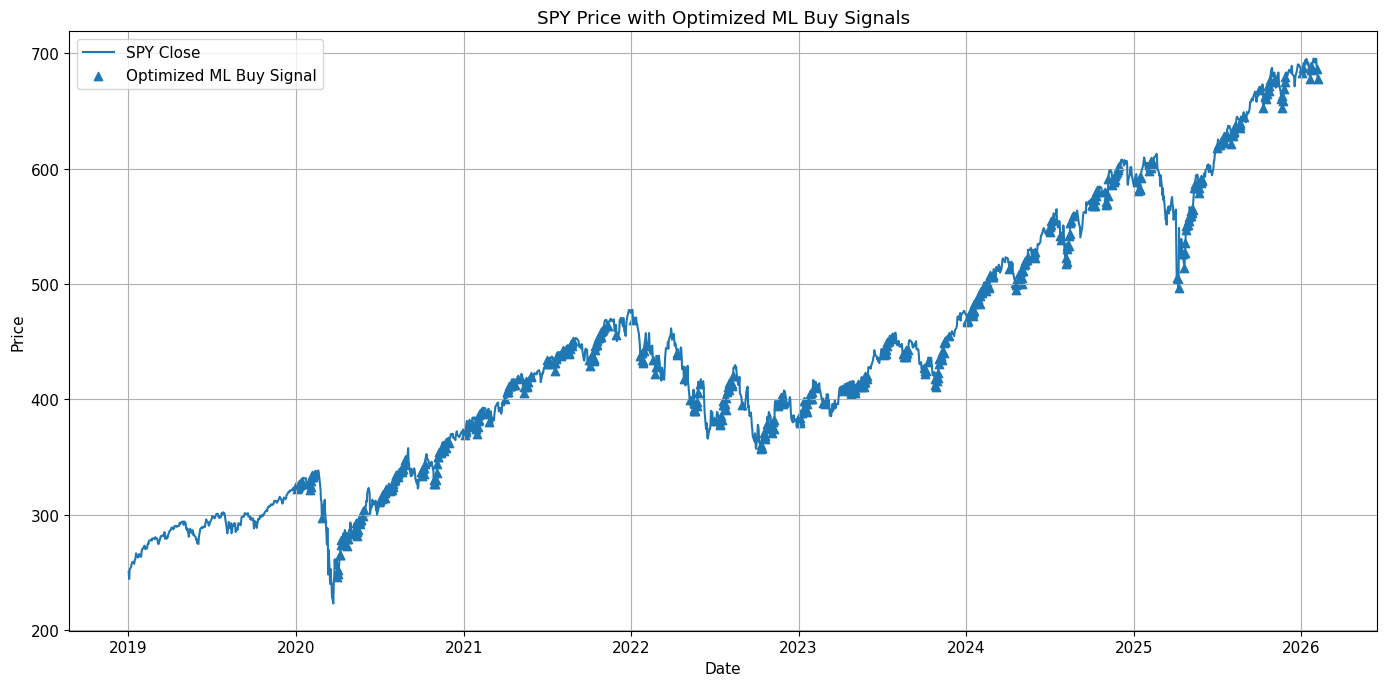

In [11]:
# ============================================
# Cell 11: Visualization of optimized ML outputs
# Purpose:
# - Inspect the behavior of optimized ML probabilities and expected returns over time
# - Make the optimized ML layer easier to interpret before optimized ensemble integration
# - Save formal diagnostic figures
# ============================================

plot_data = ml_df.loc["2019-01-01":].copy()

fig, ax = plt.subplots()
ax.plot(plot_data.index, plot_data["ml_probability_mean"], label="Mean Optimized Classification Probability")
ax.set_title("Mean Optimized ML Probability Over Time")
ax.set_xlabel("Date")
ax.set_ylabel("Probability")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "phase_5_1_ml_probability_mean.png", dpi=150)
plt.show()

fig, ax = plt.subplots()
ax.plot(plot_data.index, plot_data["ml_expected_return"], label="Mean Predicted Optimized 5-Day Score")
ax.set_title("Mean Predicted Optimized 5-Day Score")
ax.set_xlabel("Date")
ax.set_ylabel("Predicted Score")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "phase_5_1_ml_expected_return.png", dpi=150)
plt.show()

fig, ax = plt.subplots()
ax.plot(plot_data.index, plot_data["spy_close"], label="SPY Close")
ax.scatter(
    plot_data.index[plot_data["ml_signal"] == 1],
    plot_data.loc[plot_data["ml_signal"] == 1, "spy_close"],
    label="Optimized ML Buy Signal",
    marker="^",
)
ax.set_title("SPY Price with Optimized ML Buy Signals")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "phase_5_1_ml_buy_signals.png", dpi=150)
plt.show()

In [12]:
# ============================================
# Cell 12: Save Phase 5.1 outputs for Phase 6.1
# Purpose:
# - Persist all optimized machine learning predictions and meta-signals
# - Save the evaluation reports for later review
# - Maintain a stable notebook-to-notebook contract
# ============================================

phase_5_1_csv_path = PROCESSED_DIR / "phase_5_1_ml_data.csv"
phase_5_1_parquet_path = PROCESSED_DIR / "phase_5_1_ml_data.parquet"
phase_5_1_eval_csv_path = PROCESSED_DIR / "phase_5_1_ml_evaluation.csv"
phase_5_1_threshold_csv_path = PROCESSED_DIR / "phase_5_1_threshold_evaluation.csv"

ml_df.to_csv(phase_5_1_csv_path, index=True)
print(f"Saved CSV: {phase_5_1_csv_path}")

try:
    ml_df.to_parquet(phase_5_1_parquet_path, index=True)
    print(f"Saved Parquet: {phase_5_1_parquet_path}")
except Exception as e:
    print(f"Parquet save skipped: {e}")

eval_results_df.to_csv(phase_5_1_eval_csv_path, index=False)
print(f"Saved evaluation CSV: {phase_5_1_eval_csv_path}")

threshold_eval_df.to_csv(phase_5_1_threshold_csv_path, index=False)
print(f"Saved threshold evaluation CSV: {phase_5_1_threshold_csv_path}")

phase_5_1_metadata = {
    "phase": "Phase 5.1 - Machine Learning Layer (Optimized)",
    "source_notebook": "5.1 - Machine Learning Layer (Optimized).ipynb",
    "row_count": int(len(ml_df)),
    "column_count": int(ml_df.shape[1]),
    "feature_count": int(len(feature_cols)),
    "classification_models": list(classification_models.keys()),
    "regression_models": list(regression_models.keys()),
    "prediction_columns": all_prediction_cols,
    "best_buy_threshold": float(best_buy_threshold),
    "best_sell_threshold": float(best_sell_threshold),
    "start_date": str(ml_df.index.min().date()),
    "end_date": str(ml_df.index.max().date()),
}

phase_5_1_metadata_path = META_DIR / "phase_5_1_metadata.json"
with open(phase_5_1_metadata_path, "w", encoding="utf-8") as f:
    json.dump(phase_5_1_metadata, f, indent=4)

print(f"Saved metadata: {phase_5_1_metadata_path}")
print("Phase 5.1 output contract is ready for Phase 6.1.")

Saved CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_5_1_ml_data.csv
Saved Parquet: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_5_1_ml_data.parquet
Saved evaluation CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_5_1_ml_evaluation.csv
Saved threshold evaluation CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_5_1_threshold_evaluation.csv
Saved metadata: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\reports\metadata\phase_5_1_metadata.json
Phase 5.1 output contract is ready for Phase 6.1.


In [13]:
# ============================================
# Cell 13: Phase 6.1 loader snippet
# Purpose:
# - Provide a stable loading pattern for the optimized ensemble notebook
# - Keep notebook integration deterministic and easy to debug
# - Confirm the optimized ML handoff works
# ============================================

from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path.cwd()
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

phase_5_1_parquet = PROCESSED_DIR / "phase_5_1_ml_data.parquet"
phase_5_1_csv = PROCESSED_DIR / "phase_5_1_ml_data.csv"

print("Looking for Phase 5.1 files:")
print("Parquet:", phase_5_1_parquet)
print("CSV:", phase_5_1_csv)

if phase_5_1_parquet.exists():
    phase_5_1_data = pd.read_parquet(phase_5_1_parquet)
    print("Loaded Parquet file")
elif phase_5_1_csv.exists():
    phase_5_1_data = pd.read_csv(phase_5_1_csv, index_col=0, parse_dates=True)
    print("Loaded CSV file")
else:
    raise FileNotFoundError(
        "Phase 5.1 data file was not found. "
        f"Expected one of:\n{phase_5_1_parquet}\n{phase_5_1_csv}"
    )

phase_5_1_data.index = pd.to_datetime(phase_5_1_data.index)
phase_5_1_data = phase_5_1_data.sort_index()

print("\nLoaded Phase 5.1 dataset preview:")
print(phase_5_1_data.head())

Looking for Phase 5.1 files:
Parquet: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_5_1_ml_data.parquet
CSV: c:\Users\Tyler\Regime-Aware Risk Integrated Alpha\data\processed\phase_5_1_ml_data.csv
Loaded Parquet file

Loaded Phase 5.1 dataset preview:
              spy_open    spy_high     spy_low   spy_close  spy_adj_close  \
Date                                                                        
2015-02-02  200.050003  202.029999  197.860001  201.919998     167.218262   
2015-02-03  203.000000  204.850006  202.550003  204.839996     169.636398   
2015-02-04  203.919998  205.380005  203.509995  204.059998     168.990479   
2015-02-05  204.860001  206.300003  204.770004  206.119995     170.696411   
2015-02-06  206.559998  207.240005  204.919998  205.550003     170.224442   

            spy_volume  vix_close  tnx_close  is_train_period  is_live_period  \
Date                                                                            
2015-02-02   163107000